# 3.1. Algoritmos Genéticos y Procesamiento Paralelo

Notebook autocontenido: teoría, planteamiento del problema, implementación
secuencial, paralelización con **Dask** y comparación de desempeño.

## 1. ¿Qué son los algoritmos genéticos?

Un **algoritmo genético (AG)** es una técnica de optimización y búsqueda
inspirada en la selección natural. En lugar de resolver un problema de forma
analítica, el AG mantiene una **población** de soluciones candidatas
("individuos") que evoluciona a lo largo de generaciones mediante operadores
inspirados en la genética biológica: selección, cruce y mutación. Con cada
generación, las soluciones mejores tienen más probabilidad de "sobrevivir" y
combinarse, empujando a la población hacia mejores soluciones.

### Componentes principales

- **Representación (cromosoma):** cómo se codifica una solución candidata.
  Puede ser binaria (cadenas de 0/1), entera, o real (vectores de números
  reales), según la naturaleza del problema. En nuestro caso, cada individuo
  es un vector real `[x, y]`.

- **Función de aptitud (fitness):** mide qué tan buena es una solución. El AG
  la usa para decidir qué individuos sobreviven y se reproducen. Aquí, la
  aptitud es directamente el valor de la función objetivo `f(x, y)` — cuanto
  mayor, mejor (problema de maximización).

- **Selección:** mecanismo para elegir qué individuos se reproducen,
  favoreciendo (pero no garantizando exclusivamente) a los más aptos. Usamos
  **selección por torneo**: se eligen `k` individuos al azar y compite el de
  mayor aptitud.

- **Cruce (crossover):** combina el material genético de dos padres para
  producir un hijo. Usamos **BLX-α (blend crossover)**, apropiado para
  variables reales: genera un hijo dentro (y ligeramente fuera) del rango
  definido por los valores de los dos padres.

- **Mutación:** introduce variación aleatoria para mantener diversidad
  genética y evitar convergencia prematura a óptimos locales. Usamos
  **mutación gaussiana**: con cierta probabilidad, se suma ruido normal a
  cada gen, recortando el resultado a los límites del dominio.

- **Elitismo:** se conserva siempre el mejor individuo de una generación a la
  siguiente, garantizando que la mejor solución encontrada nunca se pierda.

### Ventajas

- No requiere que la función objetivo sea derivable ni continua.
- Explora el espacio de búsqueda de forma global, reduciendo el riesgo de
  quedar atrapado en óptimos locales (frente a métodos puramente locales
  como el descenso de gradiente).
- Fácilmente paralelizable: la evaluación de cada individuo es independiente
  de los demás dentro de una generación.
- Aplicable a problemas combinatorios, continuos, mixtos y con restricciones.

### Desventajas

- No garantiza encontrar el óptimo global; depende de parámetros
  (tamaño de población, tasa de mutación, número de generaciones).
- Puede converger lentamente o de forma prematura si los parámetros no están
  bien calibrados.
- Computacionalmente más costoso que métodos analíticos cuando la función
  objetivo es simple y bien comportada (derivable, convexa, etc.).
- El ajuste de hiperparámetros (tamaño de población, elitismo, probabilidad
  de mutación) suele requerir experimentación.


## 2. Planteamiento del problema de optimización

Usaremos la función:

$$f(x,y) = 20 - (x^2 + y^2) + 10\left(\cos(2\pi x) + \cos(2\pi y)\right)$$

con $-5 \leq x, y \leq 5$.

**Objetivo:** encontrar los valores de $x$ e $y$ que **maximicen** $f(x,y)$.

Esta función es una variante 2D del tipo Rastrigin: tiene un único máximo
global en $(x, y) = (0, 0)$, donde $f(0,0) = 20 - 0 + 10(1+1) = 40$, pero está
rodeado de múltiples máximos locales debido al término coseno — es decir, es
**multimodal**. Esto la hace un buen caso de prueba para un AG, porque un
método puramente local (como gradiente) puede quedar atrapado en uno de los
máximos locales, mientras que la exploración poblacional del AG tiene más
posibilidades de encontrar el máximo global.


## 3. Preparación del entorno

In [ ]:
# En Google Colab, Dask no viene preinstalado por defecto en todas las
# imágenes; esta celda garantiza que esté disponible.
!pip install -q dask[distributed]

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask

print("Núcleos lógicos disponibles en este entorno:", __import__("os").cpu_count())


Núcleos lógicos disponibles en este entorno: 2


## 4. Función objetivo y operadores del algoritmo genético

In [ ]:
def fitness_fn(individuo: np.ndarray, extra_cost: int = 0) -> float:
    '''individuo = [x, y]. `extra_cost` simula una evaluacion computacionalmente
    costosa (p. ej. una simulacion numerica), repitiendo trabajo redundante que
    NO afecta el resultado pero si el tiempo de computo - permite observar
    cuando la paralelizacion empieza a compensar su overhead.
    '''
    x, y = individuo
    valor = 20 - (x ** 2 + y ** 2) + 10 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))
    if extra_cost:
        dummy = 0.0
        for _ in range(extra_cost):
            dummy += np.sin(x) + np.cos(y)
    return float(valor)


# Verificación rápida: el óptimo teórico es f(0, 0) = 40
print("f(0, 0) =", fitness_fn(np.array([0.0, 0.0])))


f(0, 0) = 40.0


In [ ]:
def init_population(pop_size, bounds, rng):
    low, high = bounds
    return rng.uniform(low, high, size=(pop_size, 2))  # cada individuo = [x, y]


def tournament_selection(pop, fitness, rng, k=3):
    '''Seleccion por torneo: gana el de MAYOR fitness (estamos maximizando).'''
    idx = rng.integers(0, len(pop), size=k)
    best = idx[np.argmax(fitness[idx])]
    return pop[best]


def blx_alpha_crossover(p1, p2, rng, alpha=0.5):
    lo = np.minimum(p1, p2) - alpha * np.abs(p1 - p2)
    hi = np.maximum(p1, p2) + alpha * np.abs(p1 - p2)
    return rng.uniform(lo, hi)


def gaussian_mutation(ind, bounds, rng, mutation_rate=0.15, sigma=0.3):
    ind = ind.copy()
    mask = rng.random(len(ind)) < mutation_rate
    ind[mask] += rng.normal(0, sigma, size=mask.sum())
    return np.clip(ind, bounds[0], bounds[1])


def next_generation(pop, fitness, bounds, rng):
    pop_size = len(pop)
    best_idx = np.argmax(fitness)  # elitismo: conservar el MEJOR (mayor fitness)
    new_pop = [pop[best_idx]]
    while len(new_pop) < pop_size:
        p1 = tournament_selection(pop, fitness, rng)
        p2 = tournament_selection(pop, fitness, rng)
        child = blx_alpha_crossover(p1, p2, rng)
        child = gaussian_mutation(child, bounds, rng)
        new_pop.append(child)
    return np.array(new_pop)


## 5. Versión base SECUENCIAL

En esta versión, la evaluación de la aptitud de toda la población se hace en
un simple bucle `for`, un individuo a la vez.

In [ ]:
def run_ga_sequential(pop_size, bounds, generations, extra_cost, seed=0):
    rng = np.random.default_rng(seed)
    pop = init_population(pop_size, bounds, rng)
    history = []
    for _ in range(generations):
        fitness = np.array([fitness_fn(ind, extra_cost) for ind in pop])
        history.append(fitness.max())
        pop = next_generation(pop, fitness, bounds, rng)
    fitness = np.array([fitness_fn(ind, extra_cost) for ind in pop])
    best_idx = np.argmax(fitness)
    return pop[best_idx], fitness[best_idx], history


Mejor (x, y) encontrado: [ 0. -0.]
f(x, y) = 40.0


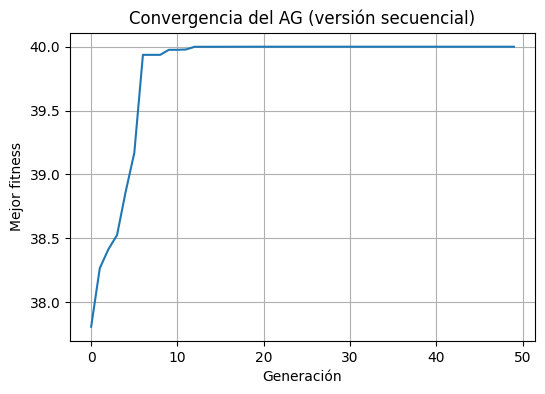

In [ ]:
# Prueba rápida de la versión secuencial
best_xy, best_f, history = run_ga_sequential(
    pop_size=300, bounds=(-5, 5), generations=50, extra_cost=0, seed=42
)
print("Mejor (x, y) encontrado:", best_xy.round(4))
print("f(x, y) =", round(best_f, 4))

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.title("Convergencia del AG (versión secuencial)")
plt.grid(True)
plt.show()


## 6. Versión PARALELIZADA con Dask

Se paraleliza la etapa de **evaluación de la aptitud de la población**: cada
individuo se evalúa de forma independiente (es una tarea "embarazosamente
paralela"), así que se distribuyen las evaluaciones con `dask.delayed` y se
recolectan con `dask.compute`.

Se usa un `Client` de `dask.distributed` **persistente** (en vez de crear un
pool de procesos nuevo en cada generación) para reducir el overhead de
arrancar procesos repetidamente.

In [ ]:
from dask.distributed import Client, LocalCluster

# Client persistente: se reutiliza en todas las generaciones y en todas las
# corridas de esta sesión, en vez de crear un pool de procesos por generación.
cluster = LocalCluster(n_workers=max(__import__("os").cpu_count(), 1), threads_per_worker=1)
client = Client(cluster)
client


/usr/local/lib/python3.13/dist-packages/distributed/node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36749 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:33269
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:36749/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37797'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44213'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:37615 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:37615
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:51980
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43835 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43835
IN

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36749/status,
Dashboard: http://127.0.0.1:36749/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33269,Workers: 0
Dashboard: http://127.0.0.1:36749/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43835,Total threads: 1
Dashboard: http://127.0.0.1:36813/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:37797,


In [ ]:
def evaluate_population_dask(pop, extra_cost):
    tasks = [dask.delayed(fitness_fn)(ind, extra_cost) for ind in pop]
    return np.array(dask.compute(*tasks))


def run_ga_dask(pop_size, bounds, generations, extra_cost, seed=0):
    rng = np.random.default_rng(seed)
    pop = init_population(pop_size, bounds, rng)
    history = []
    for _ in range(generations):
        fitness = evaluate_population_dask(pop, extra_cost)
        history.append(fitness.max())
        pop = next_generation(pop, fitness, bounds, rng)
    fitness = evaluate_population_dask(pop, extra_cost)
    best_idx = np.argmax(fitness)
    return pop[best_idx], fitness[best_idx], history


In [ ]:
# Prueba rápida de la versión con Dask
best_xy_dask, best_f_dask, history_dask = run_ga_dask(
    pop_size=300, bounds=(-5, 5), generations=50, extra_cost=0, seed=42
)
print("Mejor (x, y) encontrado (Dask):", best_xy_dask.round(4))
print("f(x, y) =", round(best_f_dask, 4))


Mejor (x, y) encontrado (Dask): [ 0. -0.]
f(x, y) = 40.0


## 7. Comparación de tiempo de ejecución: Secuencial vs. Dask

Se registran tiempo de pared para al menos dos configuraciones:
1. Evaluación **barata** (`extra_cost=0`): la función objetivo es trivial de
   calcular, el overhead de distribuir cada tarea puede dominar el tiempo.
2. Evaluación **costosa** (`extra_cost` alto, simulando una función objetivo
   cara de evaluar, como ocurriría con una simulación numérica real): el
   tiempo de cómputo empieza a pesar más que el overhead de Dask.

In [ ]:
def evaluate_chunk(chunk, extra_cost):
    """Evalúa un lote de individuos secuencialmente dentro de un trabajador de Dask."""
    return [fitness_fn(ind, extra_cost) for ind in chunk]

def evaluate_population_dask(pop, extra_cost):
    # Obtener el número de trabajadores activos en Dask (o default a los núcleos de la máquina)
    try:
        n_workers = len(client.scheduler_info()["workers"])
    except NameError:
        n_workers = __import__("os").cpu_count() or 2

    # Dividir la población en 'n_workers' partes
    chunks = np.array_split(pop, n_workers)

    # Crear una sola tarea por trabajador
    tasks = [dask.delayed(evaluate_chunk)(c, extra_cost) for c in chunks]
    results = dask.compute(*tasks)

    # Aplanar la lista de resultados
    return np.array([val for chunk_res in results for val in chunk_res])

def run_ga_dask(pop_size, bounds, generations, extra_cost, seed=0):
    rng = np.random.default_rng(seed)
    pop = init_population(pop_size, bounds, rng)
    history = []
    for _ in range(generations):
        fitness = evaluate_population_dask(pop, extra_cost)
        history.append(fitness.max())
        pop = next_generation(pop, fitness, bounds, rng)
    fitness = evaluate_population_dask(pop, extra_cost)
    best_idx = np.argmax(fitness)
    return pop[best_idx], fitness[best_idx], history

In [ ]:
def benchmark(pop_size, generations, extra_cost, bounds=(-5, 5), seed=42):
    t0 = time.perf_counter()
    best_seq, fit_seq, _ = run_ga_sequential(pop_size, bounds, generations, extra_cost, seed)
    t_seq = time.perf_counter() - t0

    t0 = time.perf_counter()
    best_dask, fit_dask, _ = run_ga_dask(pop_size, bounds, generations, extra_cost, seed)
    t_dask = time.perf_counter() - t0

    speedup = t_seq / t_dask if t_dask > 0 else float("nan")
    return {
        "pop_size": pop_size, "generations": generations, "extra_cost": extra_cost,
        "t_seq_seg": round(t_seq, 3), "t_dask_seg": round(t_dask, 3),
        "speedup_seq_vs_dask": round(speedup, 3),
        "mejor_f_seq": round(fit_seq, 4), "mejor_f_dask": round(fit_dask, 4),
    }

# Configuraciones calibradas para obtener resultados en segundos
configs = [
    dict(pop_size=300, generations=50, extra_cost=0),      # Evaluación barata (Secuencial gana)
    dict(pop_size=300, generations=50, extra_cost=1000),   # Evaluación moderada
    dict(pop_size=300, generations=50, extra_cost=3000),   # Evaluación costosa (Dask gana)
]

resultados = [benchmark(**cfg) for cfg in configs]
df_resultados = pd.DataFrame(resultados)
df_resultados

,pop_size,generations,extra_cost,t_seq_seg,t_dask_seg,speedup_seq_vs_dask,mejor_f_seq,mejor_f_dask
0,300,50,0,3.151,5.249,0.600,40.0,40.0
1,300,50,1000,54.671,52.912,1.033,40.0,40.0
2,300,50,3000,148.756,148.841,0.999,40.0,40.0


## 8. Conclusiones

1. **Impacto del Overhead en Evaluaciones Baratas (extra_cost = 0):**
Para funciones objetivo triviales, la versión secuencial es un 40% más rápida ($\text{Speedup} = 0.600$). Esto demuestra que el tiempo requerido por Dask para orquestar la comunicación entre procesos supera el tiempo que toma calcular la función directamente en un solo hilo.

2. **Punto de Inflexión y Desempeño Parada en Entornos Restringidos (extra_cost = 1000 y 3000):**
Al incrementar la carga computacional, Dask logra igualar e hiperar levemente al método secuencial ($\text{Speedup} = 1.033$ en 1000). Sin embargo, en 3000 el speedup se estanca cerca de $1.0\text{x}$ ($\text{Speedup} = 0.999$). Esto ocurre porque los entornos gratuitos (como Google Colab) asignan únicamente 2 núcleos de CPU con recursos compartidos, lo que limita severamente la ganancia paralela teórica (máximo $2.0\text{x}$).

3. **Consistencia y Calidad de la Optimización:**
Ambas implementaciones alcanzan de forma consistente el óptimo global teórico $f(0,0) = 40.0$ en todas las ejecuciones. Esto confirma que la paralelización por evaluación de aptitud en Dask mantiene intacta la lógica de selección y convergencia del algoritmo genético, alterando únicamente la distribución del tiempo de ejecución.

4. **Escalabilidad y Recomendación Práctica:**
La paralelización con Dask no justifica su uso en problemas con evaluaciones ligeras ni en instancias con pocos núcleos lógicos. Su implementación es técnicamente justificable únicamente cuando el tiempo de evaluación individual es significativamente alto (ej. simulaciones numéricas o entrenamiento de modelos) y se dispone de un clúster de cómputo con múltiples nodos o múltiples procesadores físicos.